<a href="https://colab.research.google.com/github/hunkim98/earth_science/blob/main/lectures/EPS210_Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harvard EPS-210 AI for Earth and Planetary Science

Instructor: Mostafa Mouasvi

# **Lab 6**:

**Activity 1**: 🌊 LSTM-Based Streamflow Forecasting (1-Hour Accelerated Lab)

---

---

## Learning Objectives

By the end of this lab, you will be able to:

1. Understand how **Long Short-Term Memory (LSTM)** networks model sequential hydrological processes
2. Use the **NeuralHydrology** library to train and evaluate deep learning models for rainfall–runoff prediction
3. Prepare a **GenericDataset** from real USGS streamflow and meteorological observations for CAMELS basins
4. Train a multi-basin LSTM with **static catchment attributes** — the key insight from Kratzert et al. (2019)
5. Evaluate model performance with **Nash–Sutcliffe Efficiency (NSE)** and Kling–Gupta Efficiency (KGE)

---

## Background

### Rainfall–Runoff Modeling

Predicting how much water flows through a river after a rain event — **rainfall–runoff modeling** — is one of the oldest problems in hydrology. For decades, process-based models like SAC-SMA and VIC dominated operational forecasting. In 2018–2019, a series of landmark papers showed that LSTMs could match or exceed the performance of these calibrated models across hundreds of catchments.

### The CAMELS Dataset

**CAMELS** (Catchment Attributes and MEteorology for Large-sample Studies) is a benchmark dataset of **671 catchments** across the contiguous US ([Newman et al., 2015](https://doi.org/10.5065/D6MW2F4D); [Addor et al., 2017](https://doi.org/10.5194/hess-21-5293-2017)). For each catchment, it provides:

- **Daily meteorological forcings** (precipitation, temperature, radiation, etc.) from [Daymet](https://daymet.ornl.gov/), 1980–2014
- **Daily streamflow** from USGS gauging stations
- **Static catchment attributes** — topography, climate, soil, geology, land cover, and hydrology indices

The full CAMELS download is ~15 GB. For this lab, we use data for **4 representative basins**.

### Kratzert et al. (2019): The Multi-Basin LSTM

The key insight from [Kratzert et al. (2019)](https://doi.org/10.1029/2019WR026065) — *"Toward Improved Predictions in Ungauged Basins"* — is:

> A **single LSTM** trained on **many basins simultaneously**, conditioned on **static catchment attributes**, can outperform individually calibrated hydrological models — even for basins the model has never seen during training.

The architecture concatenates static attributes (area, elevation, soil type, …) with dynamic forcings (precipitation, temperature, …) at each time step, enabling the LSTM to learn basin-specific rainfall–runoff responses.

```
Input at each timestep t:
  x_t = [precip_t, tmax_t, tmin_t, srad_t, sin(doy), cos(doy),  ← dynamic (time-varying)
         area, elevation, aridity, frac_snow, soil_depth]         ← static (constant)

  → LSTM cell → hidden state h_t → Linear head → predicted streamflow Q̂_t
```

*srad_t (Solar - surface - Radiation): It's a primary driver of evapotranspiration (ET) and snowmelt. By providing this as an input, the LSTM can learn the energy balance of the catchment. For example, high srad_t values help the model "know" when water is likely being lost to the atmosphere or when snowpacks are melting, even if temperature alone doesn't tell the full story.

*sin(doy) and cos(doy) (Cyclical Seasonal Encoding): These are the sine and cosine transformations of the Day of Year (DOY). Machine learning models struggle to understand that December 31st (DOY 365) is "close" to January 1st (DOY 1) if the day is treated as a linear number. By using these trigonometric functions: The model receives a continuous, cyclical signal of the annual season. It helps the LSTM distinguish between identical meteorological conditions that might have different runoff responses based on the time of year (e.g., a 10mm rain event in April vs. October).

### NeuralHydrology

[NeuralHydrology](https://neuralhydrology.readthedocs.io/) is an open-source Python library developed by [Kratzert et al. (2019)](https://doi.org/10.1029/2019WR026065). It provides config-file-driven training and evaluation of deep learning models for hydrology, with built-in support for CAMELS and custom datasets.

> ⚠️ **Lab scope:** We use **10 CAMELS basins** with ~14 years of data so that training completes in ~5 min on a T4 GPU. The full CAMELS benchmark (531+ basins) yields much better results due to the shared learning signal across diverse catchments.

---

## Learning Objectives

By the end of this lab, you will be able to:

1. Understand how **Long Short-Term Memory (LSTM)** networks model sequential hydrological processes
2. Use the **NeuralHydrology** library to train and evaluate deep learning models for rainfall–runoff prediction
3. Prepare a **GenericDataset** from real USGS streamflow and meteorological observations for CAMELS basins
4. Train a multi-basin LSTM with **static catchment attributes** — the key insight from Kratzert et al. (2019)
5. Evaluate model performance with **Nash–Sutcliffe Efficiency (NSE)** and Kling–Gupta Efficiency (KGE)

---

## Background

### Rainfall–Runoff Modeling

Predicting how much water flows through a river after a rain event — **rainfall–runoff modeling** — is one of the oldest problems in hydrology. For decades, process-based models like SAC-SMA and VIC dominated operational forecasting. In 2018–2019, a series of landmark papers showed that LSTMs could match or exceed the performance of these calibrated models across hundreds of catchments.

### The CAMELS Dataset

**CAMELS** (Catchment Attributes and MEteorology for Large-sample Studies) is a benchmark dataset of **671 catchments** across the contiguous US ([Newman et al., 2015](https://doi.org/10.5065/D6MW2F4D); [Addor et al., 2017](https://doi.org/10.5194/hess-21-5293-2017)). For each catchment, it provides:

- **Daily meteorological forcings** (precipitation, temperature, radiation, etc.) from [Daymet](https://daymet.ornl.gov/), 1980–2014
- **Daily streamflow** from USGS gauging stations
- **Static catchment attributes** — topography, climate, soil, geology, land cover, and hydrology indices

The full CAMELS download is ~15 GB. For this lab, we use data for **4 representative basins**.

### Kratzert et al. (2019): The Multi-Basin LSTM

The key insight from [Kratzert et al. (2019)](https://doi.org/10.1029/2019WR026065) — *"Toward Improved Predictions in Ungauged Basins"* — is:

> A **single LSTM** trained on **many basins simultaneously**, conditioned on **static catchment attributes**, can outperform individually calibrated hydrological models — even for basins the model has never seen during training.

The architecture concatenates static attributes (area, elevation, soil type, …) with dynamic forcings (precipitation, temperature, …) at each time step, enabling the LSTM to learn basin-specific rainfall–runoff responses.

```
Input at each timestep t:
  x_t = [precip_t, tmax_t, tmin_t, srad_t, sin(doy), cos(doy),  ← dynamic (time-varying)
         area, elevation, aridity, frac_snow, soil_depth]         ← static (constant)

  → LSTM cell → hidden state h_t → Linear head → predicted streamflow Q̂_t
```

*Aridity is defined as the ratio of the long-term mean annual Potential Evapotranspiration (PET) to the long-term mean annual Precipitation ($P$). This index determines the long-term water balance of a catchment and dictates how a basin will "behave" when it rains.

*srad_t (Solar - surface - Radiation): It's a primary driver of evapotranspiration (ET) and snowmelt. By providing this as an input, the LSTM can learn the energy balance of the catchment. For example, high srad_t values help the model "know" when water is likely being lost to the atmosphere or when snowpacks are melting, even if temperature alone doesn't tell the full story.

*sin(doy) and cos(doy) (Cyclical Seasonal Encoding): These are the sine and cosine transformations of the Day of Year (DOY). Machine learning models struggle to understand that December 31st (DOY 365) is "close" to January 1st (DOY 1) if the day is treated as a linear number. By using these trigonometric functions: The model receives a continuous, cyclical signal of the annual season. It helps the LSTM distinguish between identical meteorological conditions that might have different runoff responses based on the time of year (e.g., a 10mm rain event in April vs. October).

### NeuralHydrology

[NeuralHydrology](https://neuralhydrology.readthedocs.io/) is an open-source Python library developed by [Kratzert et al. (2019)](https://doi.org/10.1029/2019WR026065). It provides config-file-driven training and evaluation of deep learning models for hydrology, with built-in support for CAMELS and custom datasets.

> ⚠️ **Lab scope:** We use **4 CAMELS basins** with ~14 years of data so that training completes in ~5 min on a T4 GPU. The full CAMELS benchmark (531+ basins) yields much better results due to the shared learning signal across diverse catchments.

---
## Part 1: Setup & Installation (~3 min)

In [ ]:
#@title Install NeuralHydrology and dependencies
!pip install -q neuralhydrology netCDF4 h5netcdf xarray

import os, json, yaml, warnings, time, pickle
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime

import torch
print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU detected. Go to Runtime → Change runtime type → GPU (T4).")
    print("   Training will still work on CPU but will be slower.")

warnings.filterwarnings('ignore')
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.6/194.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 16.6 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128  |  CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


---
## Part 2: Download Real CAMELS Basin Data (~10 min)

We download daily streamflow from the **USGS National Water Information System** and meteorological forcings from the **Open-Meteo Archive API** for 4 CAMELS basins spanning diverse hydroclimates across the CONUS. These are the same basins studied in the original CAMELS dataset — we simply fetch them from public APIs rather than downloading the full 15 GB archive.

### Selected Basins

| Basin ID | River | State | Climate | Key Feature |
|----------|-------|-------|---------|-------------|
| 01013500 | Fish River | ME | Snow-dominated | Long, cold winters |
| 01170100 | Green River | MA | Humid continental | Mixed rain/snow |
| 02051500 | Meherrin River | VA | Humid subtropical | Rain-dominated |
| 03015500 | Brokenstraw Creek | PA | Humid continental | Moderate snowmelt |

In [ ]:
# ============================================================
# Basin metadata — coordinates, areas, and static attributes
# (Values from CAMELS v2.0 attributes: Addor et al., 2017)
# ============================================================
BASINS = {
    '01013500': {'name': 'Fish River, ME',          'lat': 47.24, 'lon': -68.58, 'area_km2': 2252.7,
                 'elev_mean': 230.0, 'aridity': 0.67, 'frac_snow': 0.41, 'soil_depth': 1.50, 'slope_mean': 3.76},
    '01170100': {'name': 'Green River, MA',         'lat': 42.60, 'lon': -72.60, 'area_km2': 108.3,
                 'elev_mean': 279.0, 'aridity': 0.77, 'frac_snow': 0.19, 'soil_depth': 1.46, 'slope_mean': 8.90},
    '02051500': {'name': 'Meherrin River, VA',      'lat': 36.76, 'lon': -77.85, 'area_km2': 1477.0,
                 'elev_mean': 73.0,  'aridity': 0.91, 'frac_snow': 0.03, 'soil_depth': 1.80, 'slope_mean': 2.30},
    '03015500': {'name': 'Brokenstraw Creek, PA',   'lat': 41.85, 'lon': -79.32, 'area_km2': 826.5,
                 'elev_mean': 494.0, 'aridity': 0.62, 'frac_snow': 0.16, 'soil_depth': 1.40, 'slope_mean': 5.85},
}

BASIN_IDS = sorted(BASINS.keys())
print(f"Selected {len(BASIN_IDS)} CAMELS basins:")
for bid in BASIN_IDS:
    b = BASINS[bid]
    print(f"  {bid}  {b['name']:<28s}  area={b['area_km2']:>7.1f} km²  "
          f"elev={b['elev_mean']:>5.0f} m  aridity={b['aridity']:.2f}")

Selected 4 CAMELS basins:
  01013500  Fish River, ME                area= 2252.7 km²  elev=  230 m  aridity=0.67
  01170100  Green River, MA               area=  108.3 km²  elev=  279 m  aridity=0.77
  02051500  Meherrin River, VA            area= 1477.0 km²  elev=   73 m  aridity=0.91
  03015500  Brokenstraw Creek, PA         area=  826.5 km²  elev=  494 m  aridity=0.62


In [ ]:
#@title 📥 Download, Unzip & Organize Sampled CAMELS Dataset { display-mode: "form" }
import os
import shutil
import zipfile
import gdown

from pathlib import Path
import zipfile
import pandas as pd

# Configuration
DATA_ROOT = '/content/CAMELS'
output_dir = Path(DATA_ROOT) # Defined output_dir to match DATA_ROOT
FOLDER_ID = '1YgJOa8RxklvJbCUb_3Q30hKGRw-1GDQn'
FOLDER_URL = f'https://drive.google.com/drive/folders/{FOLDER_ID}'

# 1. Setup Directory
if not os.path.exists(DATA_ROOT):
    os.makedirs(DATA_ROOT)

# 2. Download the folder recursively (getting the .zip files)
print("🚀 Starting download from Google Drive...")
# --remaining-ok allows it to proceed if some non-essential files fail
gdown.download_folder(FOLDER_URL, output=DATA_ROOT, quiet=False, remaining_ok=True)

# 3. Clean, Unzip, and Reorganize
def clean_and_reorganize():
    print("\n🧹 Cleaning up old extracted folders to prevent conflicts...")
    # Remove existing messy folders if they exist
    for folder in ['A', 'B', 'label', 'train', 'val', 'test']:
        path = os.path.join(DATA_ROOT, folder)
        # Only remove if it's a directory (don't delete the zip files yet!)
        if os.path.exists(path) and os.path.isdir(path):
            shutil.rmtree(path)

# Find the target zip file
target_name = 'camels_raw_data.zip'
found_zip = None

# 1. Search in downloaded folder
for path in output_dir.rglob('*'):
    if path.name == target_name:
        found_zip = path
        break

# 2. Fallback: Check if we have it locally from previous steps
if not found_zip:
    local_fallback = Path('/content/camels_raw_data.zip')
    if local_fallback.exists():
        print(f"⚠️ Download failed/incomplete. Using locally generated file: {local_fallback.name}")
        simulated_dl = output_dir / target_name
        shutil.copy(local_fallback, simulated_dl)
        found_zip = simulated_dl

if found_zip:
    print(f"✅ Ready to process: {found_zip.name}")

    # Unzip
    extract_path = output_dir / 'extracted'
    print(f"Extracting to {extract_path}...")
    with zipfile.ZipFile(found_zip, 'r') as z:
        z.extractall(extract_path)

    # Read and display an example
    print("\nLoading data:")
    csv_files = list(extract_path.rglob('*.csv'))
    if csv_files:
        # Sort to pick a deterministic file
        csv_files.sort()
        example_file = csv_files[0]
        df_example = pd.read_csv(example_file)
        print(f"Read file: {example_file.name}")
        print(df_example.head())
    else:
        print("No CSV files found in the zip archive.")
else:
    print(f"❌ File '{target_name}' not found. Please ensure the previous data generation step ran successfully.")

🚀 Starting download from Google Drive...


Retrieving folder contents


Processing file 1snSGV4mHJyz5AgjZvYnOVpgjyYK67-uC camels_raw_data.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1snSGV4mHJyz5AgjZvYnOVpgjyYK67-uC
To: /content/CAMELS/camels_raw_data.zip
100%|██████████| 460k/460k [00:00<00:00, 206MB/s]

✅ Ready to process: camels_raw_data.zip
Extracting to /content/CAMELS/extracted...

Loading data:
Read file: 01013500_forcing.csv
   Unnamed: 0  prcp  tmax  tmin       srad   et0
0  1996-01-01   0.0 -14.5 -20.1  70.601852  0.25
1  1996-01-02   0.0 -17.2 -23.9  73.148148  0.21
2  1996-01-03   0.0 -19.4 -25.6  49.074074  0.15
3  1996-01-04   0.0 -18.9 -24.4  64.467593  0.21
4  1996-01-05   0.5 -21.3 -25.0  66.782407  0.21



Download completed


🔄 Loading data from downloaded CSVs...
✅ Loaded 4 basins from disk: ['01013500', '01170100', '02051500', '03015500']


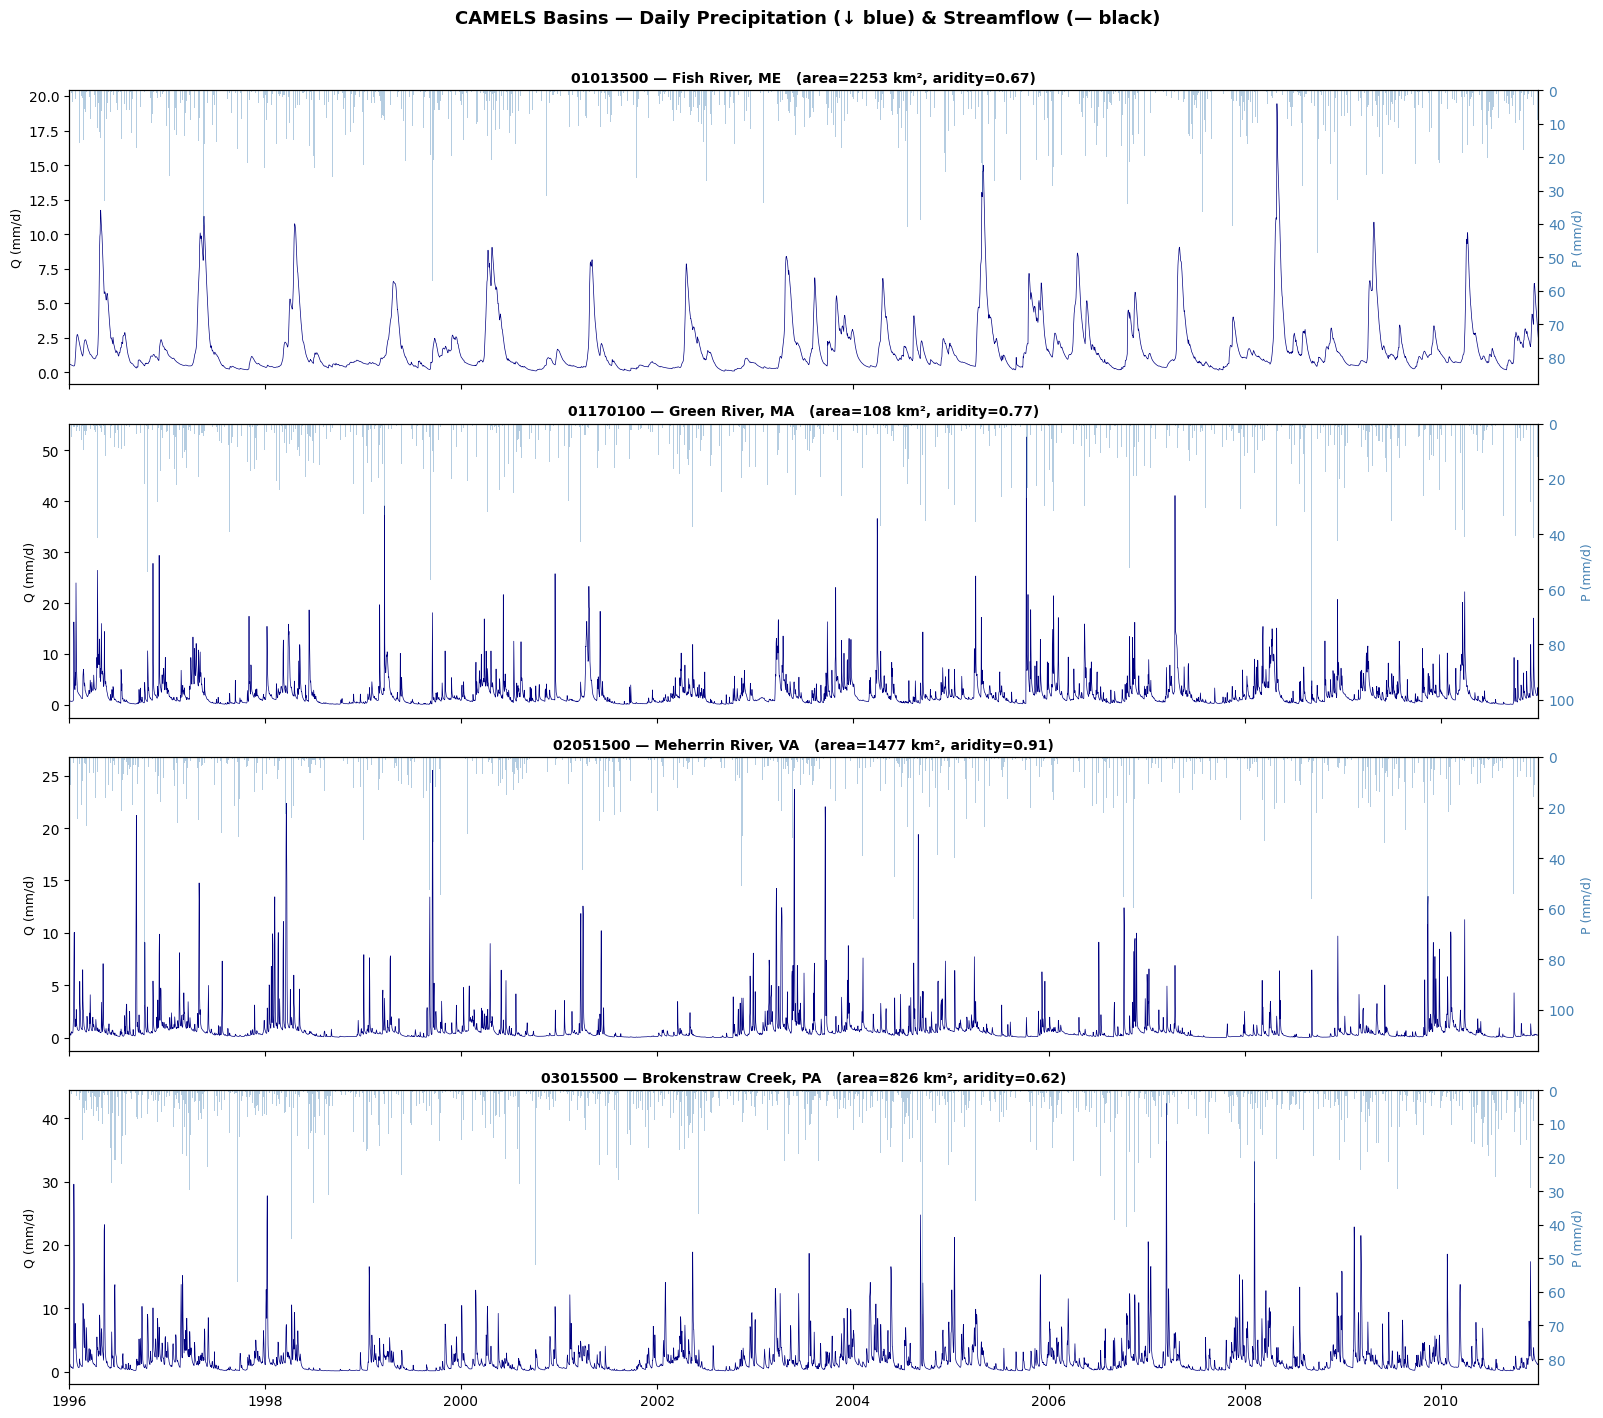

In [ ]:
# Check if data variables exist; if not, load from CSVs (Fallback for Zip workflow)
if 'streamflow_data' not in locals() or 'forcing_data' not in locals() or 'valid_basins' not in locals():
    print("🔄 Loading data from downloaded CSVs...")
    streamflow_data = {}
    forcing_data = {}

    # Check possible extraction paths
    possible_paths = [Path('/content/CAMELS/extracted'), Path('/content/drive_downloaded_data/extracted')]
    extract_path = None
    for p in possible_paths:
        if p.exists():
            extract_path = p
            break

    if extract_path:
        # Ensure BASIN_IDS exists (from metadata cell)
        ids_to_load = BASIN_IDS if 'BASIN_IDS' in locals() else [f.name.split('_')[0] for f in extract_path.glob('*_forcing.csv')]

        for bid in ids_to_load:
            # Load Forcing
            f_file = extract_path / f"{bid}_forcing.csv"
            if f_file.exists():
                df = pd.read_csv(f_file, index_col=0, parse_dates=True)
                forcing_data[bid] = df

            # Load Streamflow
            s_file = extract_path / f"{bid}_streamflow.csv"
            if s_file.exists():
                df = pd.read_csv(s_file, index_col=0, parse_dates=True)
                # Handle column names (Q_mm_day vs Q_mm)
                col = 'Q_mm_day' if 'Q_mm_day' in df.columns else 'Q_mm'
                if col in df.columns:
                    streamflow_data[bid] = df[col]
                    streamflow_data[bid].name = 'Q_mm'

    valid_basins = sorted(set(streamflow_data.keys()) & set(forcing_data.keys()))
    print(f"✅ Loaded {len(valid_basins)} basins from disk: {valid_basins}")

# Visualize the data for a few basins
if not valid_basins:
    print("⚠️ No valid basins found. Please check data download.")
else:
    fig, axes = plt.subplots(len(valid_basins[:4]), 1, figsize=(16, 3.5*min(4, len(valid_basins))),
                             sharex=True)
    if not hasattr(axes, '__len__'):
        axes = [axes]

    for idx, bid in enumerate(valid_basins[:4]):
        ax = axes[idx]
        q = streamflow_data[bid]
        p = forcing_data[bid]['prcp']

        # Plot precipitation (inverted, top)
        ax2 = ax.twinx()
        ax2.bar(p.index, p.values, width=1, color='steelblue', alpha=0.4, label='Precip')
        ax2.set_ylim(max(p.quantile(0.99)*3, 1), 0)  # Inverted
        ax2.set_ylabel('P (mm/d)', color='steelblue', fontsize=9)
        ax2.tick_params(axis='y', labelcolor='steelblue')

        # Plot streamflow
        ax.plot(q.index, q.values, color='navy', linewidth=0.5, label='Streamflow')
        ax.set_ylabel('Q (mm/d)', fontsize=9)

        # Handle missing metadata gracefully
        b_name = BASINS[bid]['name'] if 'BASINS' in locals() and bid in BASINS else bid
        b_area = BASINS[bid]['area_km2'] if 'BASINS' in locals() and bid in BASINS else 0
        b_arid = BASINS[bid]['aridity'] if 'BASINS' in locals() and bid in BASINS else 0

        ax.set_title(f"{bid} — {b_name}   "
                     f"(area={b_area:.0f} km², "
                     f"aridity={b_arid:.2f})",
                     fontsize=10, fontweight='bold')
        ax.set_xlim(q.index[0], q.index[-1])

    axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.suptitle('CAMELS Basins — Daily Precipitation (↓ blue) & Streamflow (— black)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

**Questions**  ❓

1. Compare the hydrographs. Which basins show a clear **snowmelt signal** (spring peak)? Which are more **rain-driven** (flashy, event-based)?
2. Notice the **lag** between precipitation and streamflow peaks. What physical processes cause this delay?

---
## Part 3: Prepare NeuralHydrology GenericDataset (~7 min)

<p align="center">
  <img src="https://github.com/smousavi05/Harvard-EPS-210/raw/main/figures/EPS210-L6.png" width="900">
</p>

NeuralHydrology's `GenericDataset` expects:
1. **Per-basin netCDF files** in `data_dir/time_series/<basin_id>.nc` with a `date` coordinate
2. **Static attributes CSV** in `data_dir/attributes/attributes.csv` indexed by basin ID
3. **Basin list files** (text, one basin ID per line) for train/val/test splits
4. **Config YAML** specifying model architecture, hyperparameters, and data paths

In [ ]:
# ============================================================
# Create the NeuralHydrology-compatible directory structure
# ============================================================
DATA_DIR = Path('/content/camels_mini')
TS_DIR   = DATA_DIR / 'time_series'
ATTR_DIR = DATA_DIR / 'attributes'
RUN_DIR  = Path('/content/runs')

TS_DIR.mkdir(parents=True, exist_ok=True)
ATTR_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

valid_basins = sorted(set(streamflow_data.keys()) & set(forcing_data.keys()))
print(f"Processing {len(valid_basins)} basins with complete data: {valid_basins}\n")

# Step 1: Create per-basin netCDF time series files
print("Creating per-basin netCDF files...")
for bid in valid_basins:
    # Merge forcing and streamflow into a single DataFrame
    q = streamflow_data[bid].rename('Q_mm')
    met = forcing_data[bid]

    # Align dates
    df = met.join(q, how='inner')

    # Add day-of-year features (sinusoidal encoding)
    doy = df.index.dayofyear
    df['sin_doy'] = np.sin(2 * np.pi * doy / 365.25)
    df['cos_doy'] = np.cos(2 * np.pi * doy / 365.25)

    # Replace NaN streamflow with NaN (NeuralHydrology handles this)
    # But fill forcing NaN with forward-fill then 0
    for col in ['prcp', 'tmax', 'tmin', 'srad', 'et0']:
        df[col] = df[col].fillna(method='ffill').fillna(0)

    # Convert to xarray Dataset and save as netCDF
    ds = xr.Dataset.from_dataframe(df)
    ds = ds.rename({'index': 'date'}) if 'index' in ds.dims else ds
    # Ensure the coordinate is named 'date'
    if 'date' not in ds.coords:
        dim_name = list(ds.dims.keys())[0]
        ds = ds.rename({dim_name: 'date'})

    nc_path = TS_DIR / f"{bid}.nc"
    ds.to_netcdf(nc_path)
    print(f"  ✓ {bid}: {len(df)} days, {df.columns.tolist()}")

print()

Processing 4 basins with complete data: ['01013500', '01170100', '02051500', '03015500']

Creating per-basin netCDF files...
  ✓ 01013500: 5479 days, ['prcp', 'tmax', 'tmin', 'srad', 'et0', 'Q_mm', 'sin_doy', 'cos_doy']
  ✓ 01170100: 5479 days, ['prcp', 'tmax', 'tmin', 'srad', 'et0', 'Q_mm', 'sin_doy', 'cos_doy']
  ✓ 02051500: 5479 days, ['prcp', 'tmax', 'tmin', 'srad', 'et0', 'Q_mm', 'sin_doy', 'cos_doy']
  ✓ 03015500: 5479 days, ['prcp', 'tmax', 'tmin', 'srad', 'et0', 'Q_mm', 'sin_doy', 'cos_doy']



In [ ]:
# Step 2: Create static attributes CSV
print("Creating static attributes file...")
attr_rows = []
for bid in valid_basins:
    b = BASINS[bid]
    attr_rows.append({
        'basin_id': bid,
        'area':       np.log(b['area_km2']),     # Log-transform area (common practice)
        'elev_mean':  b['elev_mean'] / 1000.0,   # Scale to km
        'aridity':    b['aridity'],
        'frac_snow':  b['frac_snow'],
        'soil_depth': b['soil_depth'],
        'slope_mean': b['slope_mean'] / 10.0,    # Scale
    })

attr_df = pd.DataFrame(attr_rows).set_index('basin_id')
attr_df.to_csv(ATTR_DIR / 'attributes.csv')
print(attr_df.round(3).to_string())
print(f"\nStatic attributes shape: {attr_df.shape}")

Creating static attributes file...
           area  elev_mean  aridity  frac_snow  soil_depth  slope_mean
basin_id                                                              
01013500  7.720      0.230     0.67       0.41        1.50       0.376
01170100  4.685      0.279     0.77       0.19        1.46       0.890
02051500  7.298      0.073     0.91       0.03        1.80       0.230
03015500  6.717      0.494     0.62       0.16        1.40       0.585

Static attributes shape: (4, 6)


In [ ]:
# Step 3: Create basin list files (train / val / test)
# Use all basins for training and evaluation (multi-basin approach).
# Though, we will use different time-periods for trainig/validation/testing.
# In the full Kratzert et al. (2019), 531 basins are used; we use our 4.

for split_name in ['train', 'val', 'test']:
    basin_file = DATA_DIR / f'basins_{split_name}.txt'
    with open(basin_file, 'w') as f:
        for bid in valid_basins:
            f.write(f"{bid}\n")
    print(f"  {split_name}: {len(valid_basins)} basins → {basin_file}")

print("\n📁 Directory structure:")
for p in sorted(DATA_DIR.rglob('*')):
    rel = p.relative_to(DATA_DIR)
    if p.is_file():
        print(f"  {rel}  ({p.stat().st_size/1024:.1f} KB)")

  train: 4 basins → /content/camels_mini/basins_train.txt
  val: 4 basins → /content/camels_mini/basins_val.txt
  test: 4 basins → /content/camels_mini/basins_test.txt

📁 Directory structure:
  attributes/attributes.csv  (0.3 KB)
  basins_test.txt  (0.0 KB)
  basins_train.txt  (0.0 KB)
  basins_val.txt  (0.0 KB)
  config.yml  (1.0 KB)
  time_series/01013500.nc  (397.0 KB)
  time_series/01170100.nc  (397.0 KB)
  time_series/02051500.nc  (397.0 KB)
  time_series/03015500.nc  (397.0 KB)


The config.yml file acts as the blueprint for an entire experiment.

Instead of hardcoding parameters into our Python scripts, we externalize all the "decisions" into a human-readable YAML file.

In [ ]:
config = {
    # --- Experiment ---
    'experiment_name': 'camels_lstm_lab',
    'run_dir': str(RUN_DIR),

    # --- Data ---
    'dataset': 'generic',
    'data_dir': str(DATA_DIR),
    'train_basin_file': str(DATA_DIR / 'basins_train.txt'),
    'validation_basin_file': str(DATA_DIR / 'basins_val.txt'),
    'test_basin_file': str(DATA_DIR / 'basins_test.txt'),

    # --- Time periods (water years) ---
    # Kratzert et al. use: Train 1999-2008, Val 1980-1989, Test 1989-1999
    # We use shorter periods for speed:
    'train_start_date': '01/10/1997',
    'train_end_date':   '30/09/2004',    # 7 water years
    'validation_start_date': '01/10/2004',
    'validation_end_date':   '30/09/2007',  # 3 water years
    'test_start_date': '01/10/2007',
    'test_end_date':   '30/09/2010',     # 3 water years

    # --- Input features ---
    'dynamic_inputs': ['prcp', 'tmax', 'tmin', 'srad', 'et0',
                       'sin_doy', 'cos_doy'],
    'target_variables': ['Q_mm'],
    'static_attributes': ['area', 'elev_mean', 'aridity',
                          'frac_snow', 'soil_depth', 'slope_mean'],

    # --- Model architecture (Kratzert et al. 2019, scaled down) ---
    # Original: hidden_size=256, seq_length=365, 30 epochs, 531 basins
    # Lab:      hidden_size=128, seq_length=270, 30 epochs, 10 basins
    'model': 'cudalstm',
    'hidden_size': 128,
    'seq_length': 270,           # ~9 months lookback
    'output_activation': 'linear',
    'head': 'regression',
    'predict_last_n': 1,

    # --- Training ---
    'batch_size': 64,
    'epochs': 50,
    'optimizer': 'Adam',
    'learning_rate': {0: 1e-3, 20: 5e-4}, # Modified to include key 0 for initial LR
    'loss': 'NSE',               # 1 - NSE loss (equivalent to MSE on standardized Q)
    'clip_gradient_norm': 1.0,

    # --- Evaluation ---
    'metrics': ['NSE', 'KGE', 'Alpha-NSE', 'Beta-NSE'],
    'validate_every': 5,
    'validate_n_random_basins': len(valid_basins),
    'save_weights_every': 3,  # Directly use the epochs value
    'log_interval': 5,

    # --- Device ---
    'device': 'cuda:0' if torch.cuda.is_available() else 'cpu',
    'num_workers': 2,
}

config_path = DATA_DIR / 'config.yml'
with open(config_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print("NeuralHydrology configuration:")
print("=" * 50)
for key, val in config.items():
    if key not in ('dynamic_inputs', 'static_attributes', 'target_variables', 'metrics'):
        print(f"  {key:<30s}: {val}")
    else:
        print(f"  {key:<30s}: {val}")

print(f"\n📝 Config saved to: {config_path}")

NeuralHydrology configuration:
  experiment_name               : camels_lstm_lab
  run_dir                       : /content/runs
  dataset                       : generic
  data_dir                      : /content/camels_mini
  train_basin_file              : /content/camels_mini/basins_train.txt
  validation_basin_file         : /content/camels_mini/basins_val.txt
  test_basin_file               : /content/camels_mini/basins_test.txt
  train_start_date              : 01/10/1997
  train_end_date                : 30/09/2004
  validation_start_date         : 01/10/2004
  validation_end_date           : 30/09/2007
  test_start_date               : 01/10/2007
  test_end_date                 : 30/09/2010
  dynamic_inputs                : ['prcp', 'tmax', 'tmin', 'srad', 'et0', 'sin_doy', 'cos_doy']
  target_variables              : ['Q_mm']
  static_attributes             : ['area', 'elev_mean', 'aridity', 'frac_snow', 'soil_depth', 'slope_mean']
  model                         : cudalstm
 

### Understanding the Configuration

Key choices from Kratzert et al. (2019):

- **`model: cudalstm`** — A CUDA-optimized LSTM implementation in NeuralHydrology. Functionally identical to a standard LSTM, but faster on GPU.

- **`seq_length: 270`** — The LSTM sees 270 days of meteorological history to predict today's streamflow. This captures seasonal memory (soil moisture, snowpack) essential for hydrological prediction.

- **`loss: NSE`** — Training minimizes `1 - NSE`, which is equivalent to mean squared error normalized by the variance of observed streamflow. This prevents basins with high discharge from dominating the loss.

<p align="center">
  <img src="https://github.com/smousavi05/Harvard-EPS-210/raw/main/figures/EPS210-L6 (1).png" width="900">
</p>

- **`static_attributes`** — These are concatenated to dynamic inputs at every timestep, telling the LSTM *which kind of basin* it's predicting for. This is the key innovation: one model learns many basins.

- **`learning_rate: {1: 1e-3, 20: 5e-4}`** — Step-wise schedule: start at 1e-3, reduce to 5e-4 at epoch 20.

---
## Part 4: Train the Multi-Basin LSTM

We use NeuralHydrology's `start_run()` to train. This handles everything: data loading, batching, normalization, training loop, validation, and logging.

In [ ]:
from neuralhydrology.nh_run import start_run, eval_run

print("Starting NeuralHydrology training (Retrying with updated config)...")
print("(Expect ~3 min on T4 GPU, ~10–15 min on CPU)")
print("=" * 50)

t0 = time.time()

if torch.cuda.is_available():
    start_run(config_file=config_path)
else:
    start_run(config_file=config_path, gpu=-1)

elapsed = time.time() - t0
print(f"\n✅ Training complete in {elapsed/60:.1f} minutes")

Starting NeuralHydrology training (Retrying with updated config)...
(Expect ~3–8 min on T4 GPU, ~10–15 min on CPU)
# Validation: 100%|██████████| 4/4 [00:00<00:00, 20.37it/s]

✅ Training complete in 0.8 minutes


In [ ]:
# Find the run directory (most recent)
run_dirs = sorted(RUN_DIR.glob('camels_lstm_lab_*'))
if run_dirs:
    run_dir = run_dirs[-1]
    print(f"Run directory: {run_dir}")
    print(f"Contents: {[p.name for p in run_dir.iterdir()]}")
else:
    print("⚠️ No run directory found. Training may have failed.")
    print("   Check the log output above for errors.")

Run directory: /content/runs/camels_lstm_lab_0203_221354
Contents: ['model_epoch030.pt', 'model_epoch036.pt', 'output.log', 'config.yml', 'optimizer_state_epoch006.pt', 'model_epoch042.pt', 'optimizer_state_epoch015.pt', 'optimizer_state_epoch018.pt', 'optimizer_state_epoch021.pt', 'model_epoch015.pt', 'model_epoch009.pt', 'optimizer_state_epoch036.pt', 'optimizer_state_epoch039.pt', 'optimizer_state_epoch048.pt', 'img_log', 'train_data', 'optimizer_state_epoch003.pt', 'model_epoch003.pt', 'optimizer_state_epoch045.pt', 'model_epoch018.pt', 'model_epoch048.pt', 'optimizer_state_epoch024.pt', 'model_epoch039.pt', 'optimizer_state_epoch042.pt', 'optimizer_state_epoch030.pt', 'optimizer_state_epoch033.pt', 'events.out.tfevents.1772489639.b38ce71d698b.9931.0', 'model_epoch027.pt', 'model_epoch024.pt', 'model_epoch045.pt', 'model_epoch021.pt', 'optimizer_state_epoch009.pt', 'optimizer_state_epoch027.pt', 'model_epoch006.pt', 'model_epoch012.pt', 'model_epoch033.pt', 'optimizer_state_epoch01

**⏱️ While the model trains**, consider the following:

1. **Why does the LSTM need 270 days of lookback?**  
   In hydrology, today's streamflow depends on soil moisture accumulated over months, snowpack built up over the winter, and groundwater recharged over even longer timescales. The LSTM learns to use this long memory.

2. **What are the LSTM gates doing physically?**  
   - **Forget gate**: Decides when to "drain" stored information (analogous to soil moisture depletion, snowmelt)
   - **Input gate**: Decides what new information to store (analogous to precipitation infiltration, snowfall)
   - **Output gate**: Decides what information drives current streamflow (analogous to runoff generation)

3. **Why train on multiple basins simultaneously?**  
   With only 4 basins, the model sees 4 different rainfall–runoff behaviors. In the full Kratzert et al. (2019) study, 531 basins provide much more diversity, enabling the model to learn general hydrological principles rather than memorizing individual basins.

---
## Part 5: Evaluate & Visualize Results (~15 min)

In [ ]:
# Run evaluation on the test period
print("Evaluating on test period (2007-10-01 to 2010-09-30)...")
eval_run(run_dir=run_dir, period='test')
print("✅ Evaluation complete")

Evaluating on test period (2007-10-01 to 2010-09-30)...
# Evaluation: 100%|██████████| 4/4 [00:00<00:00, 16.27it/s]
✅ Evaluation complete


In [ ]:
# Load test results
test_dir = run_dir / 'test'
results_file = None

if test_dir.exists():
    epoch_dirs = sorted(test_dir.glob('model_epoch*'))
    if epoch_dirs:
        results_file = epoch_dirs[-1] / 'test_results.p'

if results_file and results_file.exists():
    print(f"Loading results from: {results_file}")
    with open(results_file, 'rb') as f:
        test_results = pickle.load(f)
    print(f"\nTest results available for {len(test_results)} basins")
    print(f"Keys per basin: {list(test_results[list(test_results.keys())[0]].keys())[:5]}")
else:
    print(f"⚠️ Could not find results file in {test_dir}")

Loading results from: /content/runs/camels_lstm_lab_0203_221354/test/model_epoch048/test_results.p

Test results available for 4 basins
Keys per basin: ['1D']


In [ ]:
# Compute and display per-basin metrics
from neuralhydrology.evaluation.metrics import calculate_all_metrics

print(f"{'Basin':<12} {'Name':<28} {'NSE':>8} {'KGE':>8} {'Aridity':>8}")
print("-" * 70)

nse_values = []
kge_values = []

for bid in sorted(test_results.keys()):
    result = test_results[bid]

    # Extract observed and simulated
    obs = result['1D']['xr']['Q_mm_obs'].values
    sim = result['1D']['xr']['Q_mm_sim'].values

    # Handle potential shape issues
    if sim.ndim > 1:
        sim = sim.squeeze()
    if obs.ndim > 1:
        obs = obs.squeeze()

    # Remove NaN
    mask = ~(np.isnan(obs) | np.isnan(sim))
    obs_clean = obs[mask]
    sim_clean = sim[mask]

    if len(obs_clean) > 0:
        # NSE
        nse = 1.0 - np.sum((obs_clean - sim_clean)**2) / np.sum((obs_clean - obs_clean.mean())**2)
        # KGE
        r = np.corrcoef(obs_clean, sim_clean)[0, 1] if np.std(sim_clean) > 0 else 0
        alpha = np.std(sim_clean) / np.std(obs_clean) if np.std(obs_clean) > 0 else 0
        beta = np.mean(sim_clean) / np.mean(obs_clean) if np.mean(obs_clean) > 0 else 0
        kge = 1.0 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    else:
        nse, kge = np.nan, np.nan

    basin_name = BASINS.get(bid, {}).get('name', 'Unknown')
    aridity = BASINS.get(bid, {}).get('aridity', np.nan)
    print(f"{bid:<12} {basin_name:<28} {nse:>8.3f} {kge:>8.3f} {aridity:>8.2f}")
    nse_values.append(nse)
    kge_values.append(kge)

print("-" * 70)
print(f"{'MEDIAN':<41} {np.nanmedian(nse_values):>8.3f} {np.nanmedian(kge_values):>8.3f}")
print(f"{'MEAN':<41} {np.nanmean(nse_values):>8.3f} {np.nanmean(kge_values):>8.3f}")

Basin        Name                              NSE      KGE  Aridity
----------------------------------------------------------------------
01013500     Fish River, ME                  0.642    0.628     0.67
01170100     Green River, MA                 0.468    0.728     0.77
02051500     Meherrin River, VA              0.146    0.575     0.91
03015500     Brokenstraw Creek, PA           0.685    0.692     0.62
----------------------------------------------------------------------
MEDIAN                                       0.555    0.660
MEAN                                         0.485    0.656


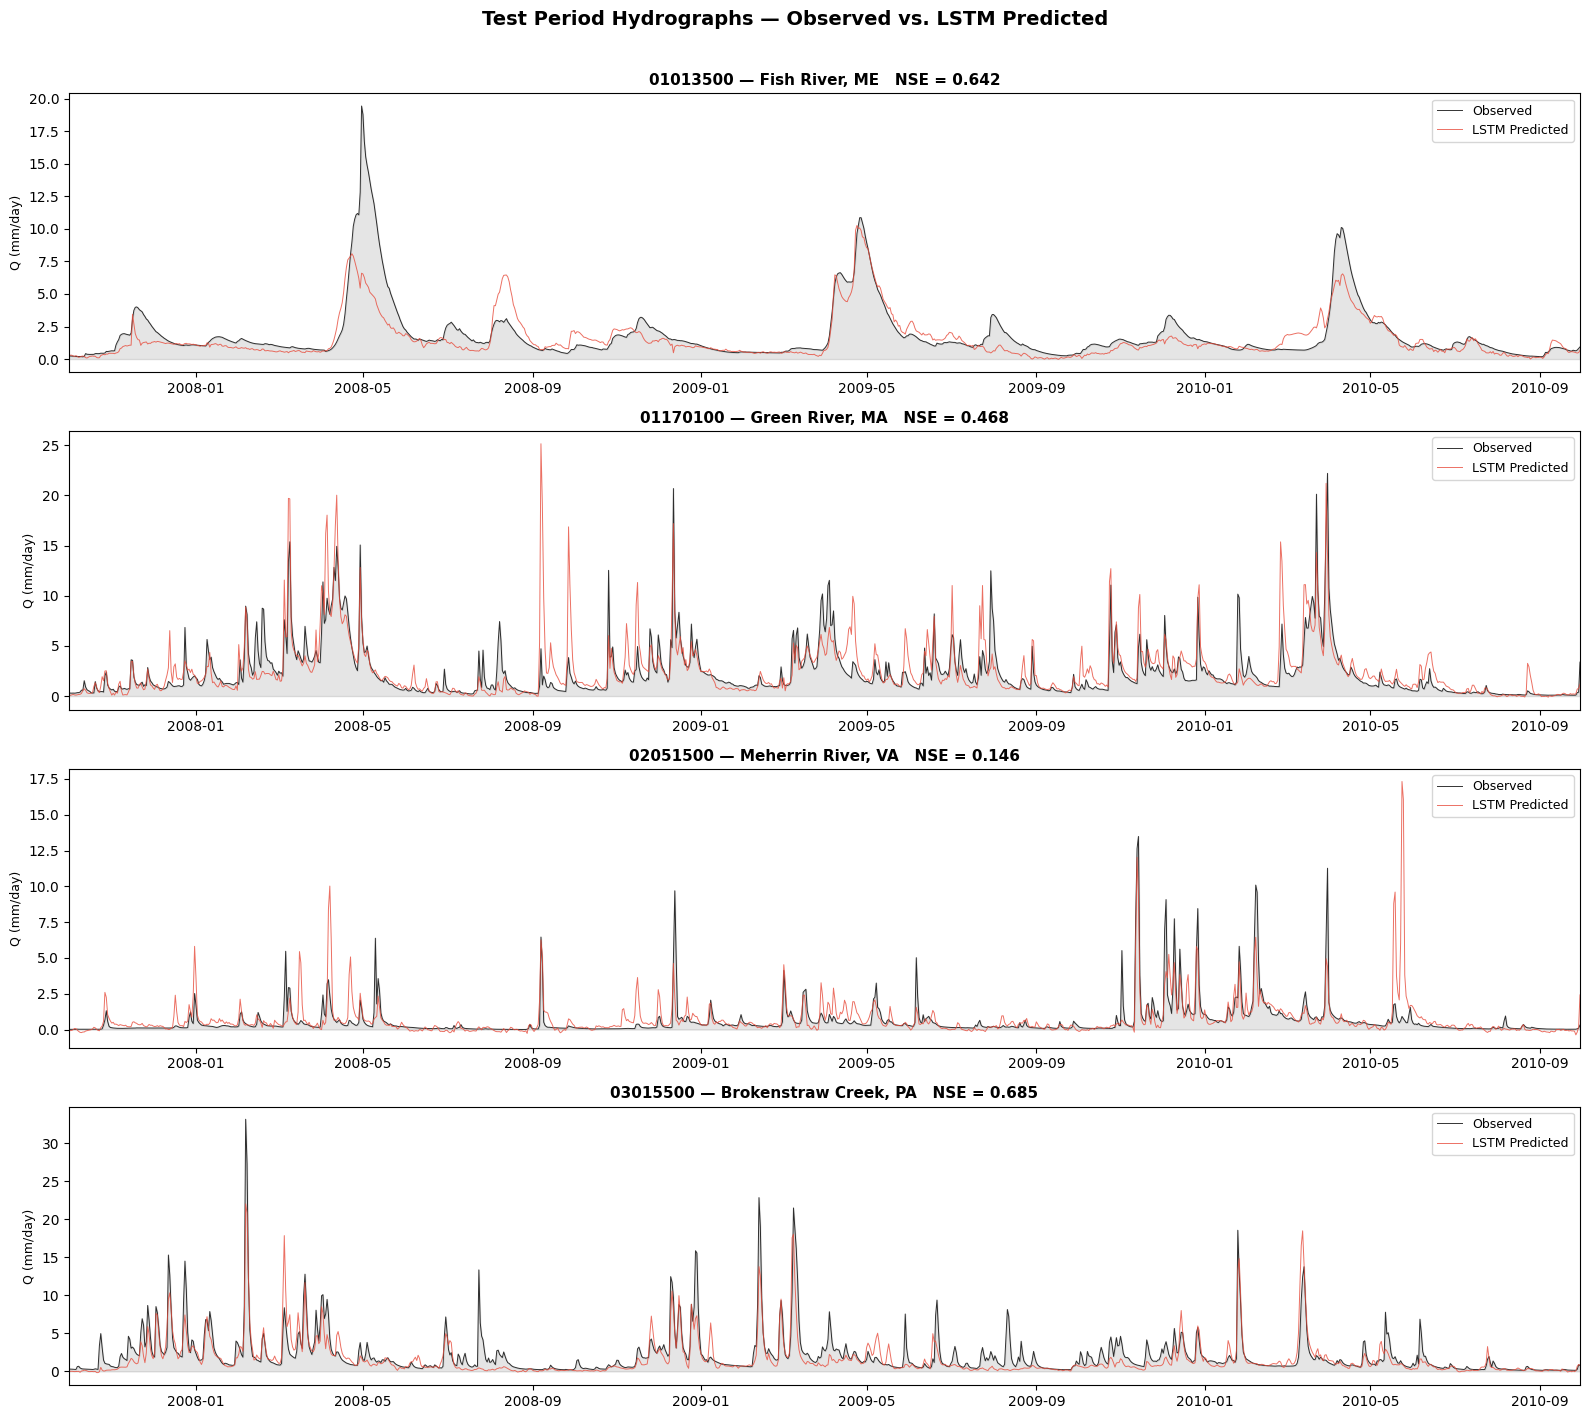

In [ ]:
# Visualize hydrographs: observed vs. predicted
n_show = min(4, len(test_results))
basins_to_plot = sorted(test_results.keys())[:n_show]

fig, axes = plt.subplots(n_show, 1, figsize=(16, 3.5 * n_show), sharex=False)
if not hasattr(axes, '__len__'):
    axes = [axes]

for idx, bid in enumerate(basins_to_plot):
    ax = axes[idx]
    result = test_results[bid]
    xr_data = result['1D']['xr']

    obs = xr_data['Q_mm_obs'].values
    sim = xr_data['Q_mm_sim'].values
    if sim.ndim > 1:
        sim = sim.squeeze()
    # FIX: Ensure obs is also 1D
    if obs.ndim > 1:
        obs = obs.squeeze()

    dates = pd.to_datetime(xr_data['date'].values)

    # Compute NSE for title
    mask = ~(np.isnan(obs) | np.isnan(sim))
    if mask.sum() > 0:
        nse = 1 - np.sum((obs[mask]-sim[mask])**2) / np.sum((obs[mask]-obs[mask].mean())**2)
    else:
        nse = np.nan

    ax.plot(dates, obs, color='black', linewidth=0.7, label='Observed', alpha=0.8)
    ax.plot(dates, sim, color='#e74c3c', linewidth=0.7, label='LSTM Predicted', alpha=0.8)
    ax.fill_between(dates, 0, obs, alpha=0.1, color='black')

    basin_name = BASINS.get(bid, {}).get('name', bid)
    ax.set_title(f"{bid} — {basin_name}   NSE = {nse:.3f}",
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Q (mm/day)', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(dates[0], dates[-1])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle('Test Period Hydrographs — Observed vs. LSTM Predicted',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

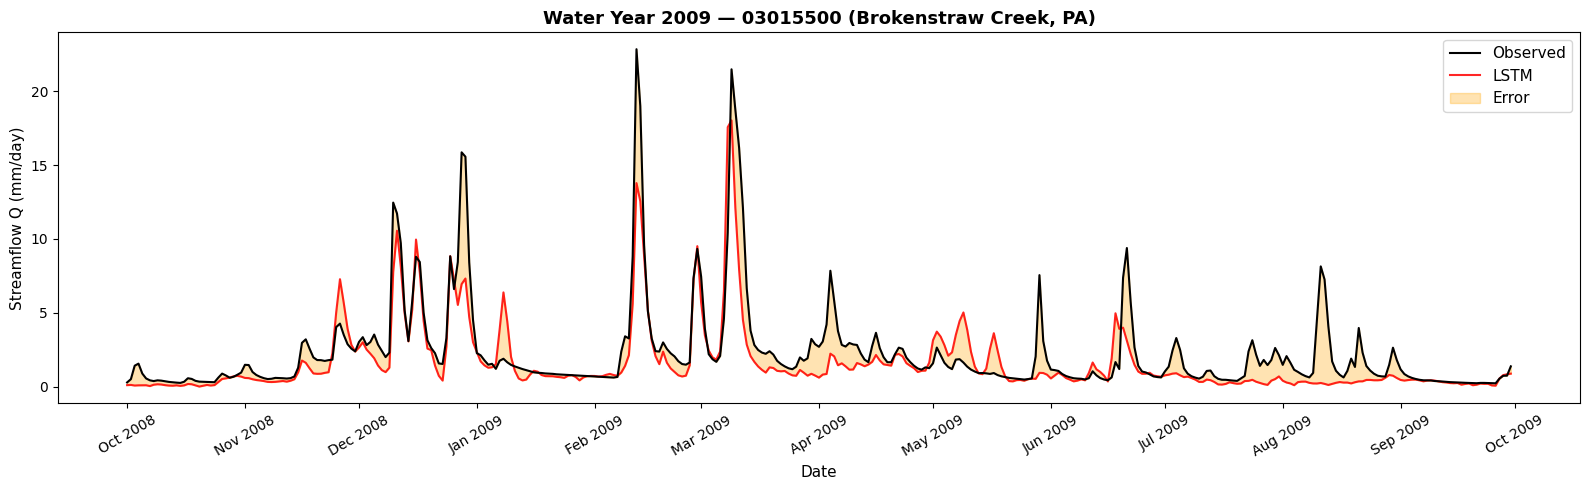

In [ ]:
# Zoom in: show one water year in detail for the best-performing basin
# We need to ensure nse_values is populated from the previous cell
if 'nse_values' not in locals() or not nse_values:
    print("⚠️ nse_values not found. Please run the metrics calculation cell first.")
else:
    best_idx = np.nanargmax(nse_values)
    basin_list = sorted(test_results.keys())
    best_bid = basin_list[best_idx]

    result = test_results[best_bid]
    xr_data = result['1D']['xr']
    obs = xr_data['Q_mm_obs'].values
    sim = xr_data['Q_mm_sim'].values
    if sim.ndim > 1:
        sim = sim.squeeze()
    if obs.ndim > 1:
        obs = obs.squeeze()

    dates = pd.to_datetime(xr_data['date'].values)

    # Focus on one water year (Oct 2008 - Sep 2009)
    mask_zoom = (dates >= '2008-10-01') & (dates <= '2009-09-30')

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(dates[mask_zoom], obs[mask_zoom], 'k-', lw=1.5, label='Observed', zorder=3)
    ax.plot(dates[mask_zoom], sim[mask_zoom], 'r-', lw=1.5, label='LSTM', zorder=2, alpha=0.85)
    ax.fill_between(dates[mask_zoom], obs[mask_zoom], sim[mask_zoom],
                    alpha=0.3, color='orange', label='Error')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Streamflow Q (mm/day)', fontsize=11)
    ax.set_title(f"Water Year 2009 — {best_bid} ({BASINS.get(best_bid,{}).get('name','?')})",
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

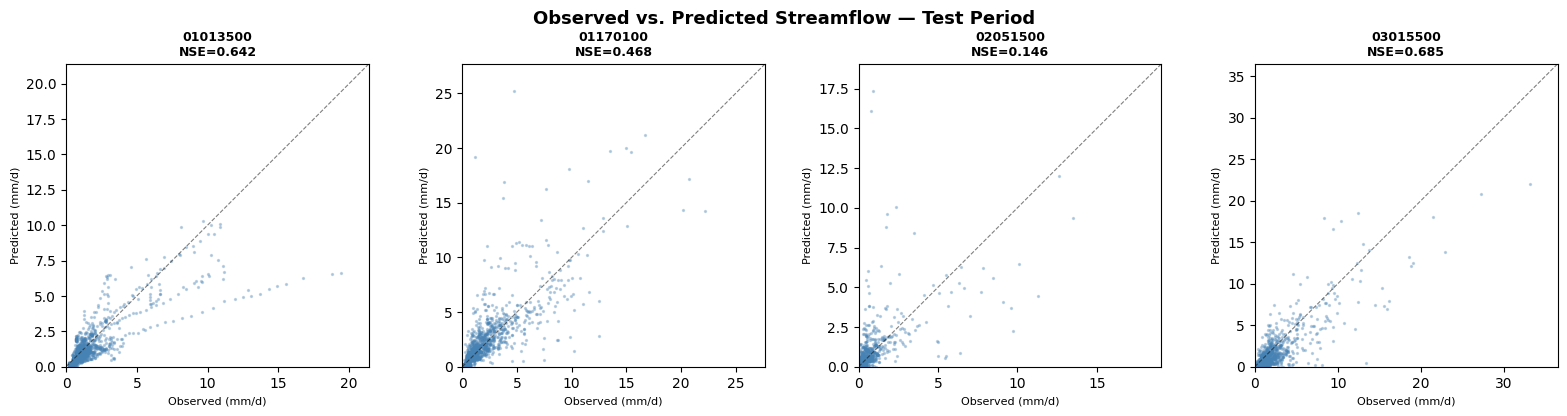

In [ ]:
# Scatter plots: Observed vs. Predicted for all basins
n_basins = len(test_results)
cols = min(5, n_basins)
rows = (n_basins + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
if n_basins == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, bid in enumerate(sorted(test_results.keys())):
    result = test_results[bid]
    obs = result['1D']['xr']['Q_mm_obs'].values
    sim = result['1D']['xr']['Q_mm_sim'].values
    if sim.ndim > 1:
        sim = sim.squeeze()
    if obs.ndim > 1:
        obs = obs.squeeze()

    mask = ~(np.isnan(obs) | np.isnan(sim))

    if mask.sum() > 0:
        nse = 1 - np.sum((obs[mask]-sim[mask])**2) / np.sum((obs[mask]-obs[mask].mean())**2)
    else:
        nse = np.nan

    ax = axes[idx]
    ax.scatter(obs[mask], sim[mask], s=2, alpha=0.3, color='steelblue')
    lim = max(obs[mask].max(), sim[mask].max()) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect('equal')
    ax.set_title(f"{bid}\nNSE={nse:.3f}", fontsize=9, fontweight='bold')
    ax.set_xlabel('Observed (mm/d)', fontsize=8)
    ax.set_ylabel('Predicted (mm/d)', fontsize=8)

for idx in range(len(test_results), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Observed vs. Predicted Streamflow — Test Period',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Generating basin characteristics analysis...


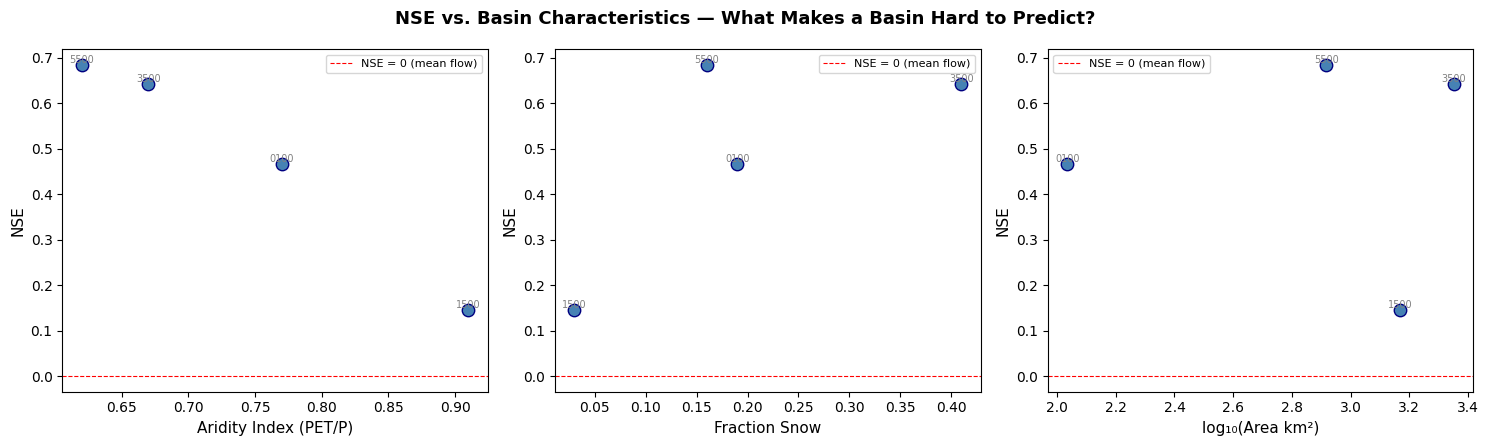

In [ ]:
# NSE vs. basin characteristics
print("Generating basin characteristics analysis...")
if 'nse_values' not in locals() or not nse_values:
    print("⚠️ nse_values not found. Please run the metrics calculation cell first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    basin_list = sorted(test_results.keys())
    nse_arr = np.array(nse_values)

    # Extract attributes ensuring order matches basin_list
    aridity_arr = np.array([BASINS.get(b, {}).get('aridity', np.nan) for b in basin_list])
    fsnow_arr = np.array([BASINS.get(b, {}).get('frac_snow', np.nan) for b in basin_list])
    area_arr = np.array([BASINS.get(b, {}).get('area_km2', np.nan) for b in basin_list])

    for ax, x, xlabel in zip(axes,
                              [aridity_arr, fsnow_arr, np.log10(area_arr)],
                              ['Aridity Index (PET/P)', 'Fraction Snow', 'log₁₀(Area km²)']):
        ax.scatter(x, nse_arr, s=80, c='steelblue', edgecolor='navy', zorder=3)
        for i, bid in enumerate(basin_list):
            ax.annotate(bid[-4:], (x[i], nse_arr[i]), fontsize=7,
                        ha='center', va='bottom', color='gray')
        ax.axhline(0, color='red', ls='--', lw=0.8, label='NSE = 0 (mean flow)')
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel('NSE', fontsize=11)
        ax.legend(fontsize=8)

    plt.suptitle('NSE vs. Basin Characteristics — What Makes a Basin Hard to Predict?',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

**❓ Questions:**

1. Which basins have the highest / lowest NSE? Can you relate this to their **aridity**, **snow fraction**, or **size**?
2. Look at the hydrographs. Does the LSTM capture **peak flows** well? What about **baseflow** (low-flow periods)?
3. An NSE of 0 means the model does no better than predicting the mean flow every day. What NSE would a traditional calibrated model achieve on these basins?
4. The NSE loss function weighs **high flows** more than **low flows** (because MSE penalizes large errors quadratically). How might this bias the model?

---
## Part 6: Analyze Training Dynamics & LSTM Memory

Analyzing a Flow Duration Curve (FDC) allows hydrologists to move beyond simple "goodness-of-fit" metrics (like NSE or R^2) and diagnose where a model is succeeding or failing across the entire spectrum of a river's behavior.

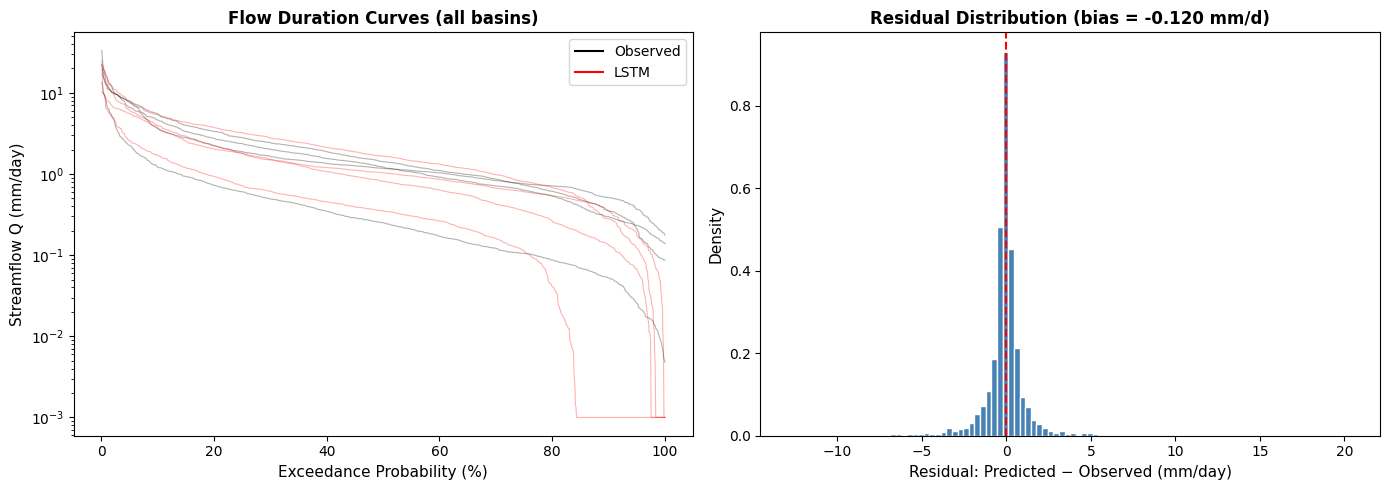

In [ ]:
# Analyze flow duration curves (FDCs): another way to evaluate hydrological models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FDC for all basins combined
all_obs, all_sim = [], []
for bid in sorted(test_results.keys()):
    result = test_results[bid]
    obs = result['1D']['xr']['Q_mm_obs'].values
    sim = result['1D']['xr']['Q_mm_sim'].values
    if sim.ndim > 1:
        sim = sim.squeeze()
    if obs.ndim > 1:
        obs = obs.squeeze()

    mask = ~(np.isnan(obs) | np.isnan(sim))
    all_obs.extend(obs[mask])
    all_sim.extend(sim[mask])

    # Per-basin FDC
    obs_sorted = np.sort(obs[mask])[::-1]
    sim_sorted = np.sort(sim[mask])[::-1]
    exceedance = np.arange(1, len(obs_sorted)+1) / len(obs_sorted) * 100
    axes[0].semilogy(exceedance, obs_sorted, 'k-', alpha=0.3, lw=0.8)
    axes[0].semilogy(exceedance, np.clip(sim_sorted, 1e-3, None), 'r-', alpha=0.3, lw=0.8)

axes[0].set_xlabel('Exceedance Probability (%)', fontsize=11)
axes[0].set_ylabel('Streamflow Q (mm/day)', fontsize=11)
axes[0].set_title('Flow Duration Curves (all basins)', fontsize=12, fontweight='bold')
from matplotlib.lines import Line2D
axes[0].legend([Line2D([0],[0],c='k',lw=1.5), Line2D([0],[0],c='r',lw=1.5)],
               ['Observed', 'LSTM'], fontsize=10)

# Residual analysis
all_obs = np.array(all_obs)
all_sim = np.array(all_sim)
residuals = all_sim - all_obs

axes[1].hist(residuals, bins=100, color='steelblue', edgecolor='white', density=True)
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Residual: Predicted − Observed (mm/day)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title(f'Residual Distribution (bias = {np.mean(residuals):.3f} mm/d)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In the context of modern machine learning models like those by Kratzert et al. (2019), FDCs are often broken down into specific "hydrological signatures."

The Anatomy of the Curve

  An FDC plots discharge ($Q$) on the y-axis (usually logarithmic) against the percentage of time that flow is equaled or exceeded on the x-axis.The
    
  **High-Flow Segment (0–10% exceedance):** It shows the response to heavy rainfall or snowmelt. A steep curve here indicates a "flashy" basin with little storage. A flat curve suggests significant flood attenuation (e.g., large lakes or floodplains).
    
  **The Mid-Range Segment (10–70% exceedance):** It shows the typical "regime" of the basin. This section is largely driven by moderate storms and the seasonal cycle.
    
  **The Low-Flow Segment (70–100% exceedance):** It shows baseflow and groundwater contribution. A horizontal "tail" suggests a robust aquifer sustaining the river during droughts. If the curve drops sharply to zero, the stream is likely intermittent or ephemeral.

**❓ Questions:**

1. Look at the **flow duration curves**. Does the LSTM capture both high flows (left side) and low flows (right side) well? Where does it deviate most?
2. Is the residual distribution **symmetric** around zero, or is there a systematic bias? What might cause this?
3. In the original Kratzert et al. (2019) with 531 basins, the median NSE was ~0.65–0.74. How does our 10-basin result compare? Why might more basins help?

---
## Part 7: Optional Experiments & Going Further (~5 min)

In [ ]:
# # ============================================================
# # EXPERIMENT A: Change the lookback period (seq_length)
# # How much memory does the LSTM need?
# # ============================================================

# # Let's test a shorter lookback (e.g., 90 days) compared to baseline (270)
# # (Full list [30, 90, 180, 365] takes longer, feel free to add them back)
# seq_test_list = [90]

# for seq_len in seq_test_list:
#     exp_name = f'camels_lstm_seq{seq_len}'
#     print(f"\nTraining with seq_length={seq_len}...")

#     # 1. Config
#     config_sl = config.copy()
#     config_sl['experiment_name'] = exp_name
#     config_sl['seq_length'] = seq_len
#     # Use same number of epochs as baseline
#     config_sl['epochs'] = config.get('epochs', 5)

#     config_sl_path = DATA_DIR / f'config_seq{seq_len}.yml'
#     with open(config_sl_path, 'w') as f:
#         yaml.dump(config_sl, f, default_flow_style=False)

#     # 2. Train
#     if torch.cuda.is_available():
#         start_run(config_file=config_sl_path)
#     else:
#         start_run(config_file=config_sl_path, gpu=-1)

#     # 3. Evaluate
#     run_dirs_sl = sorted(RUN_DIR.glob(f'{exp_name}_*'))
#     if run_dirs_sl:
#         run_dir_sl = run_dirs_sl[-1]
#         print(f"Evaluating {exp_name}...")
#         eval_run(run_dir=run_dir_sl, period='test')

#         # Simple NSE extraction
#         epoch_num = config_sl['epochs']
#         res_file = run_dir_sl / 'test' / f'model_epoch{epoch_num:03d}' / 'test_results.p'

#         # Fallback search
#         if not res_file.exists():
#              epoch_dirs = sorted((run_dir_sl / 'test').glob('model_epoch*'))
#              if epoch_dirs: res_file = epoch_dirs[-1] / 'test_results.p'

#         if res_file.exists():
#             with open(res_file, 'rb') as f:
#                 res = pickle.load(f)

#             nse_vals = []
#             for bid in res:
#                 obs = res[bid]['1D']['xr']['Q_mm_obs'].values
#                 sim = res[bid]['1D']['xr']['Q_mm_sim'].values
#                 if obs.ndim > 1: obs = obs.squeeze()
#                 if sim.ndim > 1: sim = sim.squeeze()
#                 mask = ~(np.isnan(obs) | np.isnan(sim))
#                 if mask.sum() > 0:
#                     val = 1 - np.sum((obs[mask]-sim[mask])**2) / np.sum((obs[mask]-obs[mask].mean())**2)
#                     nse_vals.append(val)

#             print(f"Results for seq_length={seq_len}:")
#             print(f"  Mean NSE: {np.nanmean(nse_vals):.3f}")
#         else:
#             print("Results file not found.")

In [ ]:
# # ============================================================
# # EXPERIMENT B: Larger model (hidden_size=256)
# # ============================================================

# config_large = config.copy()
# config_large['experiment_name'] = 'camels_lstm_h256'
# config_large['hidden_size'] = 256
# # Use same number of epochs as baseline
# config_large['epochs'] = config.get('epochs', 5)

# config_large_path = DATA_DIR / 'config_h256.yml'
# with open(config_large_path, 'w') as f:
#     yaml.dump(config_large, f, default_flow_style=False)

# if torch.cuda.is_available():
#     start_run(config_file=config_large_path)
# else:
#     start_run(config_file=config_large_path, gpu=-1)

# # Evaluate
# run_dirs_lg = sorted(RUN_DIR.glob('camels_lstm_h256_*'))
# if run_dirs_lg:
#     run_dir_lg = run_dirs_lg[-1]
#     print(f"Evaluating Larger Model...")
#     eval_run(run_dir=run_dir_lg, period='test')

#     # Simple NSE extraction
#     epoch_num = config_large['epochs']
#     res_file = run_dir_lg / 'test' / f'model_epoch{epoch_num:03d}' / 'test_results.p'

#     if not res_file.exists():
#          epoch_dirs = sorted((run_dir_lg / 'test').glob('model_epoch*'))
#          if epoch_dirs: res_file = epoch_dirs[-1] / 'test_results.p'

#     if res_file.exists():
#         with open(res_file, 'rb') as f:
#             res = pickle.load(f)

#         nse_vals = []
#         for bid in res:
#             obs = res[bid]['1D']['xr']['Q_mm_obs'].values
#             sim = res[bid]['1D']['xr']['Q_mm_sim'].values
#             if obs.ndim > 1: obs = obs.squeeze()
#             if sim.ndim > 1: sim = sim.squeeze()
#             mask = ~(np.isnan(obs) | np.isnan(sim))
#             if mask.sum() > 0:
#                 val = 1 - np.sum((obs[mask]-sim[mask])**2) / np.sum((obs[mask]-obs[mask].mean())**2)
#                 nse_vals.append(val)

#         print(f"Results for hidden_size=256:")
#         print(f"  Mean NSE: {np.nanmean(nse_vals):.3f}")

---
## 📝 Lab Wrap-Up & Discussion

### Key Takeaways

1. **LSTMs learn hydrology.** The LSTM's gating mechanism naturally maps to hydrological processes: the forget gate depletes soil moisture, the input gate captures infiltration, and the cell state acts as a basin-scale water storage.

2. **Multi-basin training enables knowledge sharing.** By training on multiple basins simultaneously with static attributes, the model learns transferable rainfall–runoff relationships. In the full Kratzert et al. (2019), this enabled strong predictions even for **ungauged basins** (basins not seen during training).

3. **Data quality matters.** We used Open-Meteo reanalysis as a proxy for Daymet. The actual CAMELS forcings (basin-averaged Daymet) would likely give better results because they account for within-basin spatial variability.

4. **Scale matters.** With 10 basins, the model has limited diversity to learn from. The full CAMELS benchmark (531 basins) spans a much wider range of hydroclimates, enabling more robust generalization.

### Discussion Questions

1. **Physical interpretability:** Unlike process-based models, the LSTM doesn't explicitly model snow accumulation, soil moisture, or groundwater. Is this a problem? How might you verify that the LSTM has learned physically consistent relationships?

2. **Climate change generalization:** LSTMs are trained on historical data. If climate change pushes basins into conditions never seen in the training period (e.g., rain instead of snow), how might the model fail? How does this compare to process-based models?

3. **Ungauged basins (PUB):** Kratzert et al. (2019) showed that a multi-basin LSTM can predict streamflow in basins with **no discharge observations**. How is this possible? What role do the static attributes play?

4. **Loss function choice:** We used NSE loss. How would using KGE loss or log-transformed NSE change model behavior, especially for low-flow prediction?

5. **From LSTM to Transformer?** Recent work explores using Transformers for hydrology. What advantages might attention mechanisms have over LSTM for rainfall–runoff modeling? What disadvantages?

### Going Further

- **Full CAMELS benchmark:** Download the [CAMELS dataset](https://ral.ucar.edu/solutions/products/camels) (~15 GB) and train on all 531 basins using NeuralHydrology's `camels_us` dataset class.
- **Prediction in Ungauged Basins (PUB):** Leave out 50 basins during training and evaluate on them — this is the Kratzert et al. (2019) experiment.
- **Data assimilation:** Feed observed streamflow back into the LSTM (autoregressive mode) using [Nearing et al. (2022)](https://doi.org/10.5194/hess-26-5493-2022).
- **Hybrid models:** Combine LSTM with process-based hydrology models using NeuralHydrology's `HybridModel` class.
- **Multi-timescale prediction:** Use the MTS-LSTM to predict both daily and hourly streamflow simultaneously.

### References

```bibtex
@article{kratzert2019toward,
  title={Toward improved predictions in ungauged basins: Exploiting the power
         of machine learning},
  author={Kratzert, Frederik and Klotz, Daniel and Herrnegger, Mathew
          and Sampson, Alden K and Hochreiter, Sepp and Nearing, Grey S},
  journal={Water Resources Research},
  volume={55}, number={12}, pages={11344--11354},
  year={2019}, doi={10.1029/2019WR026065}
}

@article{kratzert2022neuralhydrology,
  title={NeuralHydrology — A Python library for Deep Learning research
         in hydrology},
  author={Kratzert, Frederik and Gauch, Martin and Nearing, Grey and Klotz, Daniel},
  journal={Journal of Open Source Software},
  volume={7}, number={79}, pages={4050},
  year={2022}, doi={10.21105/joss.04050}
}

@article{kratzert2018rainfall,
  title={Rainfall--runoff modelling using long short-term memory (LSTM) networks},
  author={Kratzert, Frederik and Klotz, Daniel and Brenner, Claire
          and Schulz, Karsten and Herrnegger, Mathew},
  journal={Hydrology and Earth System Sciences},
  volume={22}, number={11}, pages={6005--6022},
  year={2018}, doi={10.5194/hess-22-6005-2018}
}

@article{newman2015development,
  title={Development of a large-sample watershed-scale hydrometeorological dataset
         for the contiguous USA},
  author={Newman, Andrew J and Clark, Martyn P and Sampson, Kevin and others},
  journal={Hydrology and Earth System Sciences},
  volume={19}, pages={209--223},
  year={2015}, doi={10.5194/hess-19-209-2015}
}

@article{addor2017camels,
  title={The CAMELS data set: catchment attributes and meteorology
         for large-sample studies},
  author={Addor, Nans and Newman, Andrew J and Mizukami, Naoki and Clark, Martyn P},
  journal={Hydrology and Earth System Sciences},
  volume={21}, number={10}, pages={5293--5313},
  year={2017}, doi={10.5194/hess-21-5293-2017}
}
```